In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import pickle
import os
import sys
sys.path.insert(0, '..')
from titan.Experiment import Experiment
from titan.plt_Experiment_summary import titan_plt_summary, titan_plt_summary_temp
from titan.load_and_preprocessing import titan_load_and_preprocessing
import sigmoid_fitting as sp
from titan.processing_DNA import titan_plt_infl
from scipy.ndimage import convolve1d
from sklearn.manifold import TSNE
from joblib import Parallel, delayed
from scipy import signal


%load_ext autoreload
%autoreload
sys.path.insert(0, '0_4_AMCA Code on Chip')
import chip_utilities as utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
exp_folder = "/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/trial test data/"
exp_path = Path(exp_folder, "D20250808_E00_C00_F4500KHz_U_Sample_7")
file_path = f"{exp_path}/normalised_ori_ac_df.csv"
# normalised_raw_data_nl_df.csv
curve_data = utils.denormalized(pd.read_csv(file_path))
ori_curves = curve_data.filter(like="Cycle").values
ori_timestamps = np.array([col.replace("Cycle", "") for col in curve_data.filter(like='Cycle').columns])
ori_timestamps = ori_timestamps.astype(np.float64)
ori_well = curve_data.well.values

(615,)

In [16]:
times

array([0.128, 0.256, 0.384])

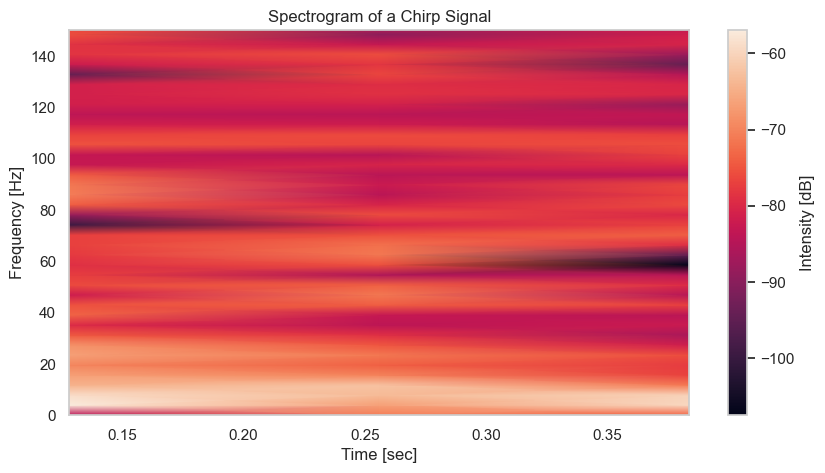

In [ ]:
# 1. Generate dummy timeseries data (a 'chirp' signal)
fs = 1000 # Sample rate (1000 Hz)
time = np.linspace(0, 2, fs * 2) # 2 seconds of data
# Signal starts at 20 Hz and sweeps up to 100 Hz
timeseries_data = signal.chirp(time, f0=20, f1=100, t1=2, method='linear')

time = ori_timestamps
timeseries_data = ori_curves[100,:]


# 2. Compute the Spectrogram (STFT)
frequencies, times, Sxx = signal.spectrogram(
    x=timeseries_data, 
    fs=fs, 
    window='hann',   # Window shape
    nperseg=256,     # Window size (length of each chunk)
    noverlap=128     # Number of overlapping points between chunks
)

# 3. Plot it
plt.figure(figsize=(10, 5))
# Sxx is usually plotted in decibels (log scale) for better visibility
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram of a Chirp Signal')
plt.colorbar(label='Intensity [dB]')
plt.ylim(0, 150) # Zoom in on the relevant frequencies
plt.show()

In [15]:
frequencies.shape

(129,)

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=615
  warnings.warn(


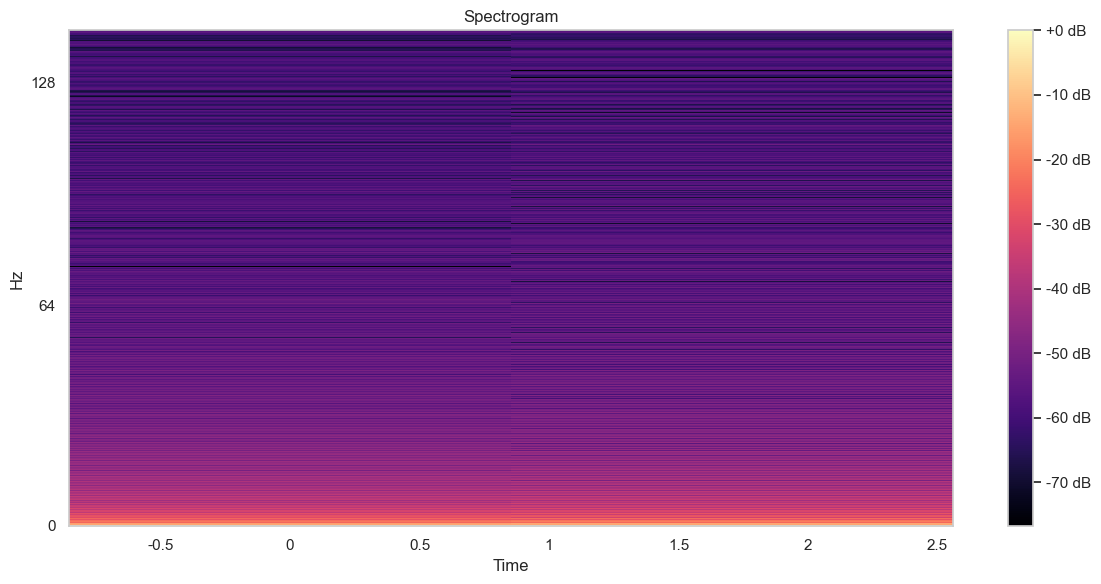

In [17]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Your time series data array
data = ori_curves[100,:]
data = data.reshape(-1)
sampling_rate = 300

# Compute the Short-Time Fourier Transform (STFT)
stft = librosa.stft(data)

# Convert the STFT to a spectrogram (magnitude of STFT)
spectrogram = np.abs(stft)

# Display the spectrogram as an image
plt.figure(figsize=(12, 6))
librosa.display.specshow(librosa.amplitude_to_db(spectrogram, ref=np.max), sr=sampling_rate, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

In [18]:
spectrogram

array([[1.01347961e+02, 1.15310431e+02],
       [8.84540218e+01, 1.00267666e+02],
       [5.62859550e+01, 6.26749835e+01],
       ...,
       [1.19130731e-01, 1.17746787e-01],
       [5.27338141e-02, 3.09499608e-02],
       [5.72719792e-02, 5.43877677e-02]], shape=(1025, 2))

In [3]:
# def first_pos_zero_crossing(data):
#     arr = np.asanyarray(data)
#     crossings = np.where((arr[1:] >= 0) & (arr[:-1] < 0))[0]
    
#     if crossings.size > 0:
#         return crossings[0] + 1
    
#     return None # No crossing found

# def lowest_integral_zero_crossing(data):
#     arr = np.asanyarray(data)
#     sign_change = np.where(np.diff(np.sign(arr)) != 0)[0]
#     boundaries = [0] + (sign_change + 1).tolist() + [len(arr)]
    
#     lowest_sum = 0
#     best_crossing_idx = None
    
#     for start, end in zip(boundaries[:-1], boundaries[1:]):
#         segment = arr[start:end]
#         segment_sum = np.sum(segment)
        
#         if segment_sum < lowest_sum:
#             lowest_sum = segment_sum
#             best_crossing_idx = start
            
#     return best_crossing_idx

# def moving_average(X, window_size=10):
#     mask = np.ones(window_size) / window_size
#     # X_avg = convolve1d(X, mask, mode='constant')
#     X_avg = convolve1d(X, mask, mode='nearest')
#     return X_avg

# def _process_single_dydx(x, y):
#     return sp.calculate_first_derivative(x, y)

# def get_curve_timestamps(df):
#     return np.array([col.replace("Cycle", "") for col in df.filter(like='Cycle').columns])

# window_size_ori = 50
# window_size_1stder = 200
# margin = (window_size_1stder - 1) // 2

# ################################################################################
# # 1. Original Curves
# ################################################################################
# ori_curves = curve_data.filter(like="Cycle").values
# ori_well = curve_data.well.values
# ori_timestamps = get_curve_timestamps(curve_data)

# ################################################################################
# # 2. Original Curves Moving Average
# ################################################################################
# ori_curves_avg = Parallel(n_jobs=-1)(
#     delayed(moving_average)(y, window_size_ori) for y in ori_curves
# )
# ori_curves_avg = np.array(ori_curves_avg)

# ################################################################################
# # 3.a. Original Curves Moving Average 1st Derivative
# ################################################################################
# ori_curve_dydx = Parallel(n_jobs=-1)(
#     delayed(_process_single_dydx)(ori_timestamps, y) for y in ori_curves
# )
# ori_curve_dydx = np.array(ori_curve_dydx)

# ################################################################################
# # 3.b. Original Curves Moving Average 1st Derivative
# ################################################################################
# ori_avg_dydx = Parallel(n_jobs=-1)(
#     delayed(_process_single_dydx)(ori_timestamps, y) for y in ori_curves_avg
# )
# ori_avg_dydx = np.array(ori_avg_dydx)

# ################################################################################
# # 4.a. Original Curves 1st Derivative Moving Average
# ################################################################################
# ori_dydx_avg = Parallel(n_jobs=-1)(
#     delayed(moving_average)(y, window_size_1stder) for y in ori_curve_dydx
# )
# ori_dydx_avg = np.array(ori_dydx_avg)

# ################################################################################
# # 4.b. Original Curves Moving Average 1st Derivative Moving Average
# ################################################################################
# ori_avg_dydx_avg = Parallel(n_jobs=-1)(
#     delayed(moving_average)(y, window_size_1stder) for y in ori_avg_dydx
# )
# ori_avg_dydx_avg = np.array(ori_avg_dydx_avg)

# ################################################################################
# # 5.a.1. Cleaned Curve 
# ################################################################################
# ori_curves_cleaned_list = []
# cleaned_idx_list = []
# for i in range(len(ori_curves)):
#     current_curve = ori_curves[i]
#     current_dydx = ori_dydx_avg[i] 

#     cross_idx = first_pos_zero_crossing(current_dydx)

#     if cross_idx is None:
#         cleaned = current_curve.copy()
#         cleaned_idx_list.append(0)
#     else:
#         actual_idx = cross_idx + margin 
#         cleaned_idx_list.append(actual_idx)
#         if actual_idx >= len(current_curve):
#             cleaned = current_curve.copy()
#         else:
#             baseline_val = current_curve[actual_idx]
#             cleaned = np.concatenate([
#                 np.full(actual_idx, baseline_val), 
#                 current_curve[actual_idx:]
#             ])
        
#     ori_curves_cleaned_list.append(cleaned)

# ori_curves_cleaned = np.array(ori_curves_cleaned_list)
# cleaned_idx = np.array(cleaned_idx_list)


# ################################################################################
# # 5.a.2. Cleaned Curve 
# ################################################################################
# ori_curves_cleaned_list = []
# cleaned_idx_list = []
# for i in range(len(ori_curves)):
#     current_curve = ori_curves[i]
#     current_dydx = ori_dydx_avg[i] 

#     cross_idx = lowest_integral_zero_crossing(current_dydx)

#     if cross_idx is None:
#         cleaned = current_curve.copy()
#         cleaned_idx_list.append(0)
#     else:
#         actual_idx = cross_idx + margin 
#         cleaned_idx_list.append(actual_idx)
#         if actual_idx >= len(current_curve):
#             cleaned = current_curve.copy()
#         else:
#             baseline_val = current_curve[actual_idx]
#             cleaned = np.concatenate([
#                 np.full(actual_idx, baseline_val), 
#                 current_curve[actual_idx:]
#             ])
        
#     ori_curves_cleaned_list.append(cleaned)

# ori_curves_cleaned_lowest = np.array(ori_curves_cleaned_list)
# cleaned_lowest_idx = np.array(cleaned_idx_list)


# ################################################################################
# # 5.b.1. Cleaned Curve using Moving Averages
# ################################################################################
# ori_curves_cleaned_list = []
# cleaned_idx_list = []
# for i in range(len(ori_curves)):
#     current_curve = ori_curves[i]
#     current_dydx = ori_avg_dydx_avg[i] 

#     cross_idx = first_pos_zero_crossing(current_dydx)

#     if cross_idx is None:
#         cleaned = current_curve.copy()
#         cleaned_idx_list.append(0)
#     else:
#         actual_idx = cross_idx + margin 
#         cleaned_idx_list.append(actual_idx)
#         if actual_idx >= len(current_curve):
#             cleaned = current_curve.copy()
#         else:
#             baseline_val = current_curve[actual_idx]
#             cleaned = np.concatenate([
#                 np.full(actual_idx, baseline_val), 
#                 current_curve[actual_idx:]
#             ])
        
#     ori_curves_cleaned_list.append(cleaned)

# ori_curves_avg_cleaned = np.array(ori_curves_cleaned_list)
# avg_cleaned_idx = np.array(cleaned_idx_list)

# ################################################################################
# # 5.b.2/ Cleaned Curve using Moving Averages
# ################################################################################
# ori_curves_cleaned_list = []
# cleaned_idx_list = []
# for i in range(len(ori_curves)):
#     current_curve = ori_curves[i]
#     current_dydx = ori_avg_dydx_avg[i] 

#     cross_idx = lowest_integral_zero_crossing(current_dydx)

#     if cross_idx is None:
#         cleaned = current_curve.copy()
#         cleaned_idx_list.append(0)
#     else:
#         actual_idx = cross_idx + margin 
#         cleaned_idx_list.append(actual_idx)
#         if actual_idx >= len(current_curve):
#             cleaned = current_curve.copy()
#         else:
#             baseline_val = current_curve[actual_idx]
#             cleaned = np.concatenate([
#                 np.full(actual_idx, baseline_val), 
#                 current_curve[actual_idx:]
#             ])
        
#     ori_curves_cleaned_list.append(cleaned)

# ori_curves_avg_lowest_cleaned = np.array(ori_curves_cleaned_list)
# avg_cleaned_lowest_idx = np.array(cleaned_idx_list)

In [4]:
def moving_average_vec(data, window_size=10):
    mask = np.ones(window_size) / window_size
    return convolve1d(data, mask, axis=-1, mode='nearest')

def first_pos_zero_crossing_vec(data_2d):
    crossings = (data_2d[:, 1:] >= 0) & (data_2d[:, :-1] < 0)
    indices = np.argmax(crossings, axis=1) + 1
    exists = np.any(crossings, axis=1)
    return np.where(exists, indices, 0)

def lowest_integral_to_next_crossing_vec(data_2d):
    def single_lowest_exit(arr):
        sign_change = np.where(np.diff(np.sign(arr)) != 0)[0]
        boundaries = [0] + (sign_change + 1).tolist() + [len(arr)]
        
        lowest_sum = 0
        best_exit_idx = 0  # Default to 0 if no negative segment found
        
        for start, end in zip(boundaries[:-1], boundaries[1:]):
            segment_sum = np.sum(arr[start:end])
            if segment_sum < lowest_sum:
                lowest_sum = segment_sum
                best_exit_idx = end
                
        return best_exit_idx
    
    return np.array([single_lowest_exit(row) for row in data_2d])

def apply_baseline_cleaning(curves, cross_indices, margin):
    cleaned = curves.copy()
    actual_indices = np.clip(cross_indices + margin, 0, curves.shape[1] - 1)
    
    mask = cross_indices > 0
    
    for i in range(len(curves)):
        if mask[i]:
            idx = actual_indices[i]
            cleaned[i, :idx] = curves[i, idx]
            
    return cleaned, np.where(mask, actual_indices, 0)

In [5]:
window_size_ori = 50
window_size_1stder = 200
margin = (window_size_1stder - 1) // 2

ori_curves = curve_data.filter(like="Cycle").values
ori_timestamps = np.array([col.replace("Cycle", "") for col in curve_data.filter(like='Cycle').columns])
ori_timestamps = ori_timestamps.astype(np.float64)
ori_well = curve_data.well.values

# Smooth curves
ori_curves_avg = moving_average_vec(ori_curves, window_size_ori)

def get_derivatives(curves_batch):
    return Parallel(n_jobs=-1)(
        delayed(sp.calculate_first_derivative)(ori_timestamps, y) for y in curves_batch
    )

# First derivatives
ori_curve_dydx = np.array(get_derivatives(ori_curves))
ori_avg_dydx = np.array(get_derivatives(ori_curves_avg))

# Smooth derivatives
ori_dydx_avg = moving_average_vec(ori_curve_dydx, window_size_1stder)
ori_avg_dydx_avg = moving_average_vec(ori_avg_dydx, window_size_1stder)

# Curves cleaning
cleaning_tasks = [
    ("std", ori_dydx_avg, first_pos_zero_crossing_vec),
    ("low", ori_dydx_avg, lowest_integral_to_next_crossing_vec),
    ("avg_std", ori_avg_dydx_avg, first_pos_zero_crossing_vec),
    ("avg_low", ori_avg_dydx_avg, lowest_integral_to_next_crossing_vec)
]

results = {}
for name, deriv, func in cleaning_tasks:
    indices = func(deriv)
    cleaned_curves, actual_idxs = apply_baseline_cleaning(ori_curves, indices, margin)
    results[name] = (cleaned_curves, actual_idxs)

ori_curves_cleaned, cleaned_idx = results["std"]
ori_curves_cleaned_lowest, cleaned_lowest_idx = results["low"]
ori_curves_avg_cleaned, avg_cleaned_idx = results["avg_std"]
ori_curves_avg_lowest_cleaned, avg_cleaned_lowest_idx = results["avg_low"]

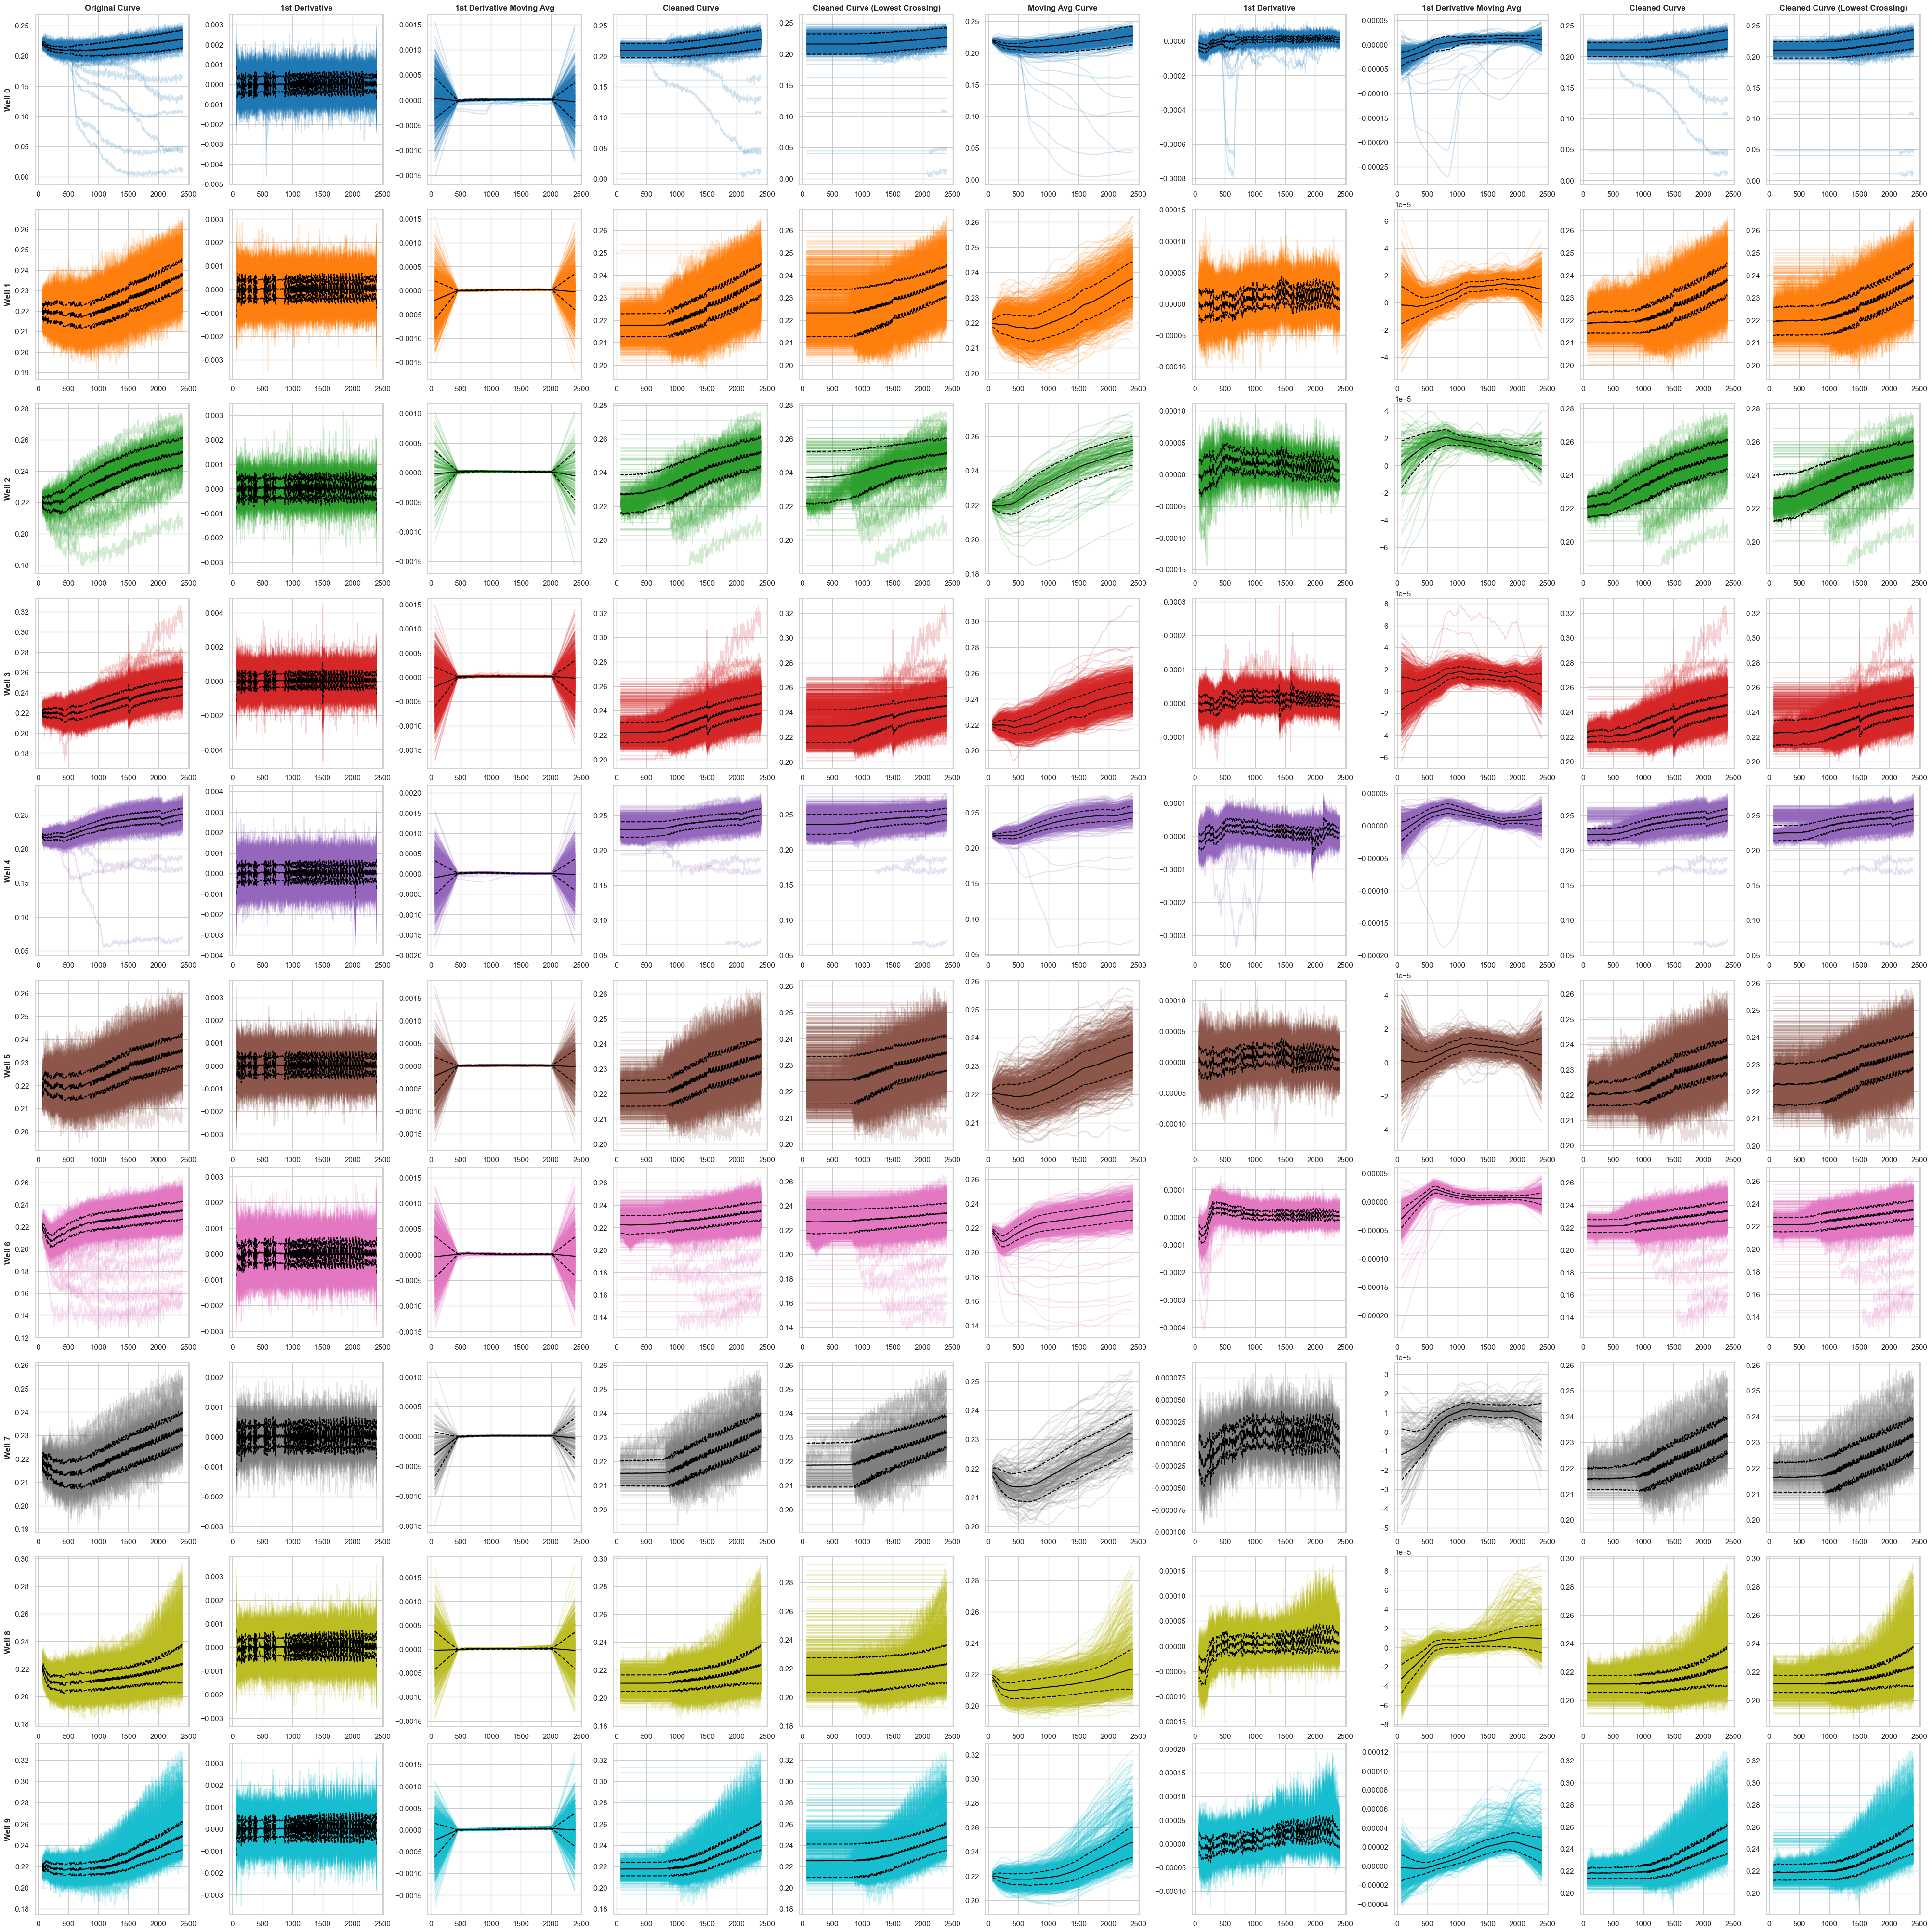

In [6]:
processed_curves = [ori_curves, ori_curve_dydx, ori_dydx_avg, ori_curves_cleaned, ori_curves_cleaned_lowest, ori_curves_avg, ori_avg_dydx, ori_avg_dydx_avg, ori_curves_avg_cleaned, ori_curves_avg_lowest_cleaned]
curve_labels = ["Original Curve", "1st Derivative", "1st Derivative Moving Avg", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)", "Moving Avg Curve", "1st Derivative", "1st Derivative Moving Avg", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)"]

unique_wells = np.unique(ori_well)
num_wells = len(unique_wells)
num_cols = len(processed_curves)
wh_constant = 4

fig, axes = plt.subplots(num_wells, num_cols, 
                         figsize=(wh_constant * num_cols, wh_constant * num_wells),
                         constrained_layout=True)

for col_idx, label in enumerate(curve_labels):
    axes[0, col_idx].set_title(label, fontweight='bold')

for row_idx, well in enumerate(unique_wells):
    mask = (ori_well == well)
    well_color = plt.cm.tab10(row_idx % 10)
    
    for col_idx, curves in enumerate(processed_curves):
        ax = axes[row_idx, col_idx]
        y_data = curves[mask].T
        y_mean = np.mean(y_data, axis=1)
        y_std = np.std(y_data, axis=1)
        
        ax.plot(ori_timestamps, y_data, color=well_color, alpha=0.2)
        ax.plot(ori_timestamps, y_mean, color="black")
        ax.plot(ori_timestamps, y_mean - y_std, color="black", linestyle='dashed')
        ax.plot(ori_timestamps, y_mean + y_std, color="black", linestyle='dashed')
        
        if col_idx == 0:
            ax.set_ylabel(f"Well {well}", fontweight='bold')

plt.show()

In [ ]:
import numpy as np
import matplotlib.colors as mcolors
from bokeh.plotting import figure, show, output_file
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource

# 1. Output settings
output_file("interactive_curves.html", title="Interactive Well Curves")

processed_curves = [ori_curves, ori_curve_dydx, ori_dydx_avg, ori_curves_cleaned, ori_curves_cleaned_lowest, ori_curves_avg, ori_avg_dydx, ori_avg_dydx_avg, ori_curves_avg_cleaned, ori_curves_avg_lowest_cleaned]
curve_labels = ["Original Curve", "1st Derivative", "1st Derivative Moving Avg", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)", "Moving Avg Curve", "1st Derivative", "1st Derivative Moving Avg", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)"]

# --- 1. DOUBLE DOT MAPPING ---
col_to_idx_map = {
    0: (cleaned_idx, cleaned_lowest_idx), 
    1: (cleaned_idx, cleaned_lowest_idx), 
    2: (cleaned_idx, cleaned_lowest_idx), 
    3: (cleaned_idx,),
    4: (cleaned_lowest_idx,),
    5: (avg_cleaned_idx, avg_cleaned_lowest_idx), 
    6: (avg_cleaned_idx, avg_cleaned_lowest_idx), 
    7: (avg_cleaned_idx, avg_cleaned_lowest_idx), 
    8: (avg_cleaned_idx,),
    9: (avg_cleaned_lowest_idx,)
}

unique_wells = np.unique(ori_well)
num_wells = len(unique_wells)
num_cols = len(processed_curves)

plot_size = 350 
grid_plots = []

# Columns that should display the Mean and +/- Std lines
stats_cols = {0, 3, 4, 5, 8, 9}

for row_idx, well in enumerate(unique_wells):
    mask = (ori_well == well)
    
    mpl_color = plt.cm.tab10(row_idx % 10)
    hex_color = mcolors.to_hex(mpl_color)
    
    num_curves_in_well = np.sum(mask)
    
    data_dict = {
        'xs': [ori_timestamps for _ in range(num_curves_in_well)],
        'color': [hex_color] * num_curves_in_well
    }
    
    for col_idx, curves in enumerate(processed_curves):
        # Line data
        data_dict[f'ys_{col_idx}'] = list(curves[mask])
        
        # --- 2. EXTRACT 1 OR 2 MARKERS ---
        idx_tuple = col_to_idx_map[col_idx]
        
        # Primary Marker
        idx_1 = idx_tuple[0][mask]
        data_dict[f'mx1_{col_idx}'] = ori_timestamps[idx_1]
        data_dict[f'my1_{col_idx}'] = curves[mask][np.arange(num_curves_in_well), idx_1]
        
        # Secondary Marker (if the tuple has two elements)
        if len(idx_tuple) > 1:
            idx_2 = idx_tuple[1][mask]
            data_dict[f'mx2_{col_idx}'] = ori_timestamps[idx_2]
            data_dict[f'my2_{col_idx}'] = curves[mask][np.arange(num_curves_in_well), idx_2]
            
    source = ColumnDataSource(data=data_dict)
    
    row_plots = []
    for col_idx in range(num_cols):
        title = curve_labels[col_idx] if row_idx == 0 else ""
        
        p = figure(title=title, width=plot_size, height=plot_size,
                   tools="pan,wheel_zoom,box_zoom,reset,tap")
        
        if col_idx == 0:
            p.yaxis.axis_label = f"Well {well}"

        # --- Draw the interactive curves ---
        p.multi_line(xs='xs', ys=f'ys_{col_idx}', color='color', source=source,
                     line_width=1.0, alpha=0.15,
                     selection_color="black", selection_alpha=1.0, selection_line_width=2.5,
                     nonselection_color=hex_color, nonselection_alpha=0.05)
        
        # --- 3. DRAW MARKERS (Grey -> Red on Click) ---
        # Draw Primary Marker (Updated to scatter to fix deprecation warning)
        p.scatter(x=f'mx1_{col_idx}', y=f'my1_{col_idx}', source=source,
                  size=4, color="grey", alpha=0.25,
                  selection_color="red", selection_alpha=1.0,
                  nonselection_color="grey", nonselection_alpha=0.05)
        
        # Draw Secondary Marker if applicable
        if len(col_to_idx_map[col_idx]) > 1:
            p.scatter(x=f'mx2_{col_idx}', y=f'my2_{col_idx}', source=source,
                      size=4, color="grey", alpha=0.25,
                      selection_color="red", selection_alpha=1.0,
                      nonselection_color="grey", nonselection_alpha=0.05)
        
         # --- NEW: DRAW MEAN AND STD LINES (Background, Non-Selectable) ---
        if col_idx in stats_cols:
            # Extract raw 2D numpy array for math (Rows: curves, Cols: timestamps)
            y_array = processed_curves[col_idx][mask]
            y_mean = np.nanmean(y_array, axis=0)
            y_std = np.nanstd(y_array, axis=0)
            
            # Mean Line
            p.line(x=ori_timestamps, y=y_mean, color="red", line_width=0.5,
                   selection_color="red", selection_alpha=1.0,
                   nonselection_color="red", nonselection_alpha=1.0)
            
            # + Std Line
            p.line(x=ori_timestamps, y=y_mean + y_std, color="red", line_width=0.25, line_dash="dashed",
                   selection_color="red", selection_alpha=0.8,
                   nonselection_color="red", nonselection_alpha=0.8)
            
            # - Std Line
            p.line(x=ori_timestamps, y=y_mean - y_std, color="red", line_width=0.25, line_dash="dashed",
                   selection_color="red", selection_alpha=0.8,
                   nonselection_color="red", nonselection_alpha=0.8)

        row_plots.append(p)
        
    grid_plots.append(row_plots)


# --- Linked Panning/Zooming with Split Y-Axes ---
group_a_cols = [0, 3, 4, 5, 8, 9]
group_b_cols = [1, 2, 6, 7]

for r in range(num_wells):
    for c in range(num_cols):
        # Link X-axis globally
        if r != 0 or c != 0:
            grid_plots[r][c].x_range = grid_plots[0][0].x_range
            
        # Link Y-axis ONLY within the specified groups per row
        if c in group_a_cols and c != group_a_cols[0]:
            grid_plots[r][c].y_range = grid_plots[r][group_a_cols[0]].y_range
        elif c in group_b_cols and c != group_b_cols[0]:
            grid_plots[r][c].y_range = grid_plots[r][group_b_cols[0]].y_range

# Build the grid and display
grid = gridplot(grid_plots)
show(grid)

In [30]:
def _fit_single_curve(y_row, x_time, start_idx=0):
    try:
        y_num = np.asanyarray(y_row, dtype=np.float64)
        x_num = np.asanyarray(x_time, dtype=np.float64)
        
        y_fit = y_num[start_idx:]
        x_fit = x_num[start_idx:]
        
        params, _ = sp.fit_5p(x_fit, y_fit, normalize=True)
        
        # 3. Evaluate the curve over the FULL time domain. 
        # Since x_num matches y_num in length, fitted_full will exactly match y_num's dimension.
        fitted_full = sp.sigmoid_5p(x_num, *params)
            
        # 4. Calculate RMSE strictly on the fitted portion to remain accurate
        rmse = np.sqrt(np.nanmean(np.square(fitted_full[start_idx:] - y_fit)))
        
        return fitted_full, params, rmse
        
    except (TypeError, ValueError, Exception):
        return np.full_like(x_time, np.nan, dtype=np.float64), np.full(5, np.nan), np.nan

def sigmoid_fitting_5p(curves, ori_timestamps, starting_idxs=None):
    if starting_idxs is None:
        results = Parallel(n_jobs=-1, backend="threading")(
            delayed(_fit_single_curve)(y, ori_timestamps, 0) for y in curves
        )
    else:
        results = Parallel(n_jobs=-1, backend="threading")(
            delayed(_fit_single_curve)(y, ori_timestamps, t) for y, t in zip(curves, starting_idxs)
        )
        
    curves_out, params_out, rmse_out = zip(*results)
    return np.array(curves_out), np.array(params_out), np.array(rmse_out)

In [ ]:
curves_and_starting_idx = [
    (ori_curves, None),
    (ori_curves_cleaned, cleaned_idx),
    (ori_curves_cleaned_lowest, cleaned_lowest_idx),
    (ori_curves_avg, None),
    (ori_curves_avg_cleaned, avg_cleaned_idx),
    (ori_curves_avg_lowest_cleaned, avg_cleaned_lowest_idx)
]

fitting_results = []
for (curves, starting_idxs) in curves_and_starting_idx:
    fitting_results.append(sigmoid_fitting_5p(curves, ori_timestamps, starting_idxs))

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/gk_code/sigmoid_fitting.py:16: RuntimeWarning: overflow encountered in power
  return Fm / (1.0 + np.exp(-Sc * (x - Cs)))**As + Fb
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/gk_code/sigmoid_fitting.py:16: RuntimeWarning: overflow encountered in exp
  return Fm / (1.0 + np.exp(-Sc * (x - Cs)))**As + Fb


In [ ]:
processed_curves = [ori_curves, ori_curve_dydx, ori_dydx_avg, ori_curves_cleaned, ori_curves_cleaned_lowest, ori_curves_avg, ori_avg_dydx, ori_avg_dydx_avg, ori_curves_avg_cleaned, ori_curves_avg_lowest_cleaned]
sigmoid_fit_cols = [0, 3, 4, 5, 8, 9]

for col in sigmoid_fit_cols:
    

In [ ]:
processed_curves = [ori_curves, ori_curves_cleaned, ori_curves_cleaned_lowest, ori_curves_avg_cleaned, ori_curves_avg_lowest_cleaned]
curve_labels = ["Original Curve", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)", "Cleaned Avg Curve", "Cleaned Avg Curve (Lowest Crossing)"]


In [ ]:
processed_curves = [ori_curves, ori_curve_dydx, ori_dydx_avg, ori_curves_cleaned, ori_curves_cleaned_lowest, ori_curves_avg, ori_avg_dydx, ori_avg_dydx_avg, ori_curves_avg_cleaned, ori_curves_avg_lowest_cleaned]
curve_labels = ["Original Curve", "1st Derivative", "1st Derivative Moving Avg", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)", "Moving Avg Curve", "1st Derivative", "1st Derivative Moving Avg", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)"]

processed_curves = [ori_curves, ori_curves_cleaned, ori_curves_cleaned_lowest, ori_curves_avg_cleaned, ori_curves_avg_lowest_cleaned]
curve_labels = ["Original Curve", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)", "Cleaned Avg Curve", "Cleaned Avg Curve (Lowest Crossing)"]

unique_wells = np.unique(ori_well)
num_wells = len(unique_wells)
num_cols = len(processed_curves)
wh_constant = 4

fig, axes = plt.subplots(num_wells, num_cols, 
                         figsize=(wh_constant * num_cols, wh_constant * num_wells),
                         constrained_layout=True)

for col_idx, label in enumerate(curve_labels):
    axes[0, col_idx].set_title(label, fontweight='bold')

for row_idx, well in enumerate(unique_wells):
    mask = (ori_well == well)
    well_color = plt.cm.tab10(row_idx % 10)
    
    for col_idx, curves in enumerate(processed_curves):
        ax = axes[row_idx, col_idx]
        y_data = curves[mask].T
        y_mean = np.mean(y_data, axis=1)
        y_std = np.std(y_data, axis=1)
        
        ax.plot(ori_timestamps, y_data, color=well_color, alpha=0.2)
        ax.plot(ori_timestamps, y_mean, color="black")
        ax.plot(ori_timestamps, y_mean - y_std, color="black", linestyle='dashed')
        ax.plot(ori_timestamps, y_mean + y_std, color="black", linestyle='dashed')
        
        if col_idx == 0:
            ax.set_ylabel(f"Well {well}", fontweight='bold')

plt.show()

In [ ]:
processed_curves = [ori_curves, ori_curves_cleaned, ori_curves_cleaned_lowest, ori_curves_avg_cleaned, ori_curves_avg_lowest_cleaned]
curve_labels = ["Original Curve", "Cleaned Curve", "Cleaned Curve (Lowest Crossing)", "Cleaned Avg Curve", "Cleaned Avg Curve (Lowest Crossing)"]

unique_wells = np.unique(ori_well)
num_wells = len(unique_wells)
num_cols = len(processed_curves)
wh_constant = 4

fig, axes = plt.subplots(num_wells, num_cols, 
                         figsize=(wh_constant * num_cols, wh_constant * num_wells),
                         constrained_layout=True)

for col_idx, label in enumerate(curve_labels):
    axes[0, col_idx].set_title(label, fontweight='bold')

for row_idx, well in enumerate(unique_wells):
    mask = (ori_well == well)
    well_color = plt.cm.tab10(row_idx % 10)
    
    for col_idx, curves in enumerate(processed_curves):
        ax = axes[row_idx, col_idx]
        
        y_raw = curves[mask].T  
        
        y_min = y_raw.min(axis=0)
        y_max = y_raw.max(axis=0)
        
        y_range = y_max - y_min
        y_range[y_range == 0] = 1.0
        
        y_data = (y_raw - y_min) / y_range
        
        y_mean = np.mean(y_data, axis=1)
        y_std = np.std(y_data, axis=1)
        
        ax.plot(ori_timestamps, y_data, color=well_color, alpha=0.15, linewidth=0.8)
        ax.plot(ori_timestamps, y_mean, color="black", linewidth=1.5, label="Mean")
        ax.plot(ori_timestamps, y_mean - y_std, color="black", linestyle='--', alpha=0.4)
        ax.plot(ori_timestamps, y_mean + y_std, color="black", linestyle='--', alpha=0.4)
        
        ax.set_ylim(-0.05, 1.05)
        
        if col_idx == 0:
            ax.set_ylabel(f"Well {well}", fontweight='bold')

In [ ]:
fig, axes = plt.subplots(num_wells, num_cols, 
                         figsize=(wh_constant * num_cols, wh_constant * num_wells),
                         constrained_layout=True)
ylim_min = np.min(sigmoid_fitting_curves) - 0.05
ylim_max = np.max(sigmoid_fitting_curves) + 0.05

for ax, label in zip(axes[0], curve_labels):
    ax.set_title(label, fontweight='bold')

for row_idx, well in enumerate(unique_wells):
    mask = (ori_well == well)
    well_color = plt.cm.tab10(row_idx % 10)

    row_data_all = [curves_set[mask].astype(np.float64) for curves_set in sigmoid_fitting_curves]
    row_min = min(np.nanmin(data) for data in row_data_all) - 0.05
    row_max = max(np.nanmax(data) for data in row_data_all) + 0.05

    for col_idx, curves_set in enumerate(sigmoid_fitting_curves):
        ax = axes[row_idx, col_idx]

        y_data = curves_set[mask].T  
        # y_data = np.array(y_data, dtype=np.float64)
        
        y_mean = np.nanmean(y_data, axis=1)
        y_std = np.nanstd(y_data, axis=1)
        
        ax.plot(ori_timestamps, y_data, color=well_color, alpha=0.15, linewidth=0.8)
        
        ax.plot(ori_timestamps, y_mean, color="black", linewidth=1.5, label="Mean")
        ax.plot(ori_timestamps, y_mean - y_std, color="black", linestyle='--', alpha=0.4)
        ax.plot(ori_timestamps, y_mean + y_std, color="black", linestyle='--', alpha=0.4)
        
        ax.set_ylim(row_min, row_max)
        if col_idx == 0:
            ax.set_ylabel(f"Well {well}", fontweight='bold')

In [ ]:
import matplotlib.pyplot as plt

# Use a faster backend if available
# plt.switch_backend('macosx') 

fig, axes = plt.subplots(num_wells, num_cols, 
                         figsize=(wh_constant * num_cols, wh_constant * num_wells),
                         constrained_layout=True)

# Pre-define labels for the M3's memory
titles = [label for label in curve_labels]

for row_idx, well in enumerate(unique_wells):
    mask = (ori_well == well)
    well_color = plt.cm.tab10(row_idx % 10)
    
    for col_idx, curves_set in enumerate(sigmoid_fitting_curves):
        ax = axes[row_idx, col_idx]
        
        y_raw = curves_set[mask].T 
        y_raw = np.array(y_raw, dtype=np.float64)
        
        y_min = np.nanmin(y_raw, axis=0)
        y_max = np.nanmax(y_raw, axis=0)
        y_range = np.where((y_max - y_min) == 0, 1.0, y_max - y_min)
        
        y_data = (y_raw - y_min) / y_range
        
        # Statistics
        y_mean = np.nanmean(y_data, axis=1)
        y_std = np.nanstd(y_data, axis=1)
        
        # Drawing
        ax.plot(ori_timestamps, y_data, color=well_color, alpha=0.15, linewidth=0.8)
        ax.plot(ori_timestamps, y_mean, color="black", linewidth=1.5)
        
        # fill_between is faster to render than multiple dashed lines
        ax.fill_between(ori_timestamps, y_mean - y_std, y_mean + y_std, 
                        color="black", alpha=0.1, zorder=3)
        
        ax.set_ylim(-0.05, 1.05)
        if row_idx == 0:
            ax.set_title(titles[col_idx], fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(f"Well {well}", fontweight='bold')

In [ ]:
fig, ax = plt.subplots(10,3, figsize=(3*6,40))
for well in np.unique(ori_well):
    idx = np.where(ori_well==well)
    X = ori_timestamps
    
    y_curves = ori_curves[idx]
    ax[well][0].plot(X, y_curves.T, color=plt.cm.tab10(well), alpha=0.2)
    ax[well][0].set_title(f"Well-{well}")

    y_curve_dydx = ori_curve_dydx[idx]
    ax[well][1].plot(X, y_curve_dydx.T, color=plt.cm.tab10(well), alpha=0.2)
    ax[well][1].set_title(f"Well-{well} 1st derivative")
    
    y_curve_dydx_moving_avg = ori_curve_dydx_moving_avg[idx]
    ax[well][2].plot(X[margin:-margin], y_curve_dydx_moving_avg[:,margin:-margin].T, color=plt.cm.tab10(well), alpha=0.2)
    ax[well][2].set_title(f"Well-{well} smoothed 1st derivative")

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(10,2, figsize=(12,40))
for well in np.unique(ori_well):
    idx = np.where(ori_well==well)
    X = ori_timestamps
    
    y_curves = ori_curves[idx]
    ax[well][0].plot(X, y_curves.T, color=plt.cm.tab10(well), alpha=0.2)
    ax[well][0].set_title(f"Well-{well}")

    y_curve_dydx = ori_curve_dydx[idx]
    ax[well][1].plot(X, y_curve_dydx.T, color=plt.cm.tab10(well), alpha=0.2)
    ax[well][1].set_title(f"Well-{well}")
    
plt.tight_layout()
plt.show()

In [ ]:
for i, df in enumerate(curve_dfs):
    fig, ax = plt.subplots(1, 10, figsize=(60, 6))
    for well in np.unique(df["well"]):
        idx = np.where(df["well"]==well)
        X = [col.replace("Cycle", "") for col in df.filter(like='Cycle').columns]
        y = df.filter(like='Cycle').values[idx]
        ax[well].plot(X, y.T, color=plt.cm.tab10(well), alpha=0.2)
        ax[well].set_title(f"Well-{well}")
    
    fig.suptitle(curve_names[i])
    plt.tight_layout()
    plt.show()